# OLIST Basic Insights Dashboard
**Input and output folder**

`C:\Users\mbach\Documents\olist-data-platform\analysis\outputs`

The notebook reads the CSV/JSON analysis outputs from that folder and saves all generated dashboard images back into the same folder.

### Expected files

- `monthly_sales.csv`
- `top50_products_by_month.csv`
- `category_by_state_revenue.csv`
- `customer_segments.csv`
- `delivery_by_state.csv`
- `gold_customer_categories.csv`
- `top50_sellers.csv`
- `kpis.json`

### Deliverable flow

`Kaggle → Meltano → BigQuery → dbt / analytics → CSV outputs → Jupyter dashboard → report / presentation`


## 1. Imports and fixed Windows path

In [4]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

BASE_DIR = Path(r"C:\Users\mbach\Documents\olist-data-platform\analysis\outputs")
OUTPUT_DIR = BASE_DIR

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Using folder:")
print(BASE_DIR)
print("Exists:", BASE_DIR.exists())

if not BASE_DIR.exists():
    raise FileNotFoundError(f"Folder not found: {BASE_DIR}")


Using folder:
C:\Users\mbach\Documents\olist-data-platform\analysis\outputs
Exists: True


## 2. Check the files in your analysis output folder

In [3]:
files = sorted([p.name for p in BASE_DIR.iterdir() if p.is_file()])
for name in files:
    print(name)


01_monthly_revenue.png
02_top50_revenue_by_category.png
03_categories_and_states.png
04_segment_revenue_share.png
05_delivery_days_by_state.png
06_delivery_days_vs_late_rate.png
07_volume_vs_late_rate.png
category_by_state_revenue.csv
customer_segments.csv
delivery_by_state.csv
gold_customer_categories.csv
kpis.json
monthly_sales.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv
top50_products_by_month.csv
top50_sellers.csv


## 3. Load CSV and JSON analysis outputs

In [5]:
monthly_sales = pd.read_csv(BASE_DIR / "monthly_sales.csv", parse_dates=["month_start"])
top50_products = pd.read_csv(BASE_DIR / "top50_products_by_month.csv", parse_dates=["month_start"])
category_state = pd.read_csv(BASE_DIR / "category_by_state_revenue.csv")
customer_segments = pd.read_csv(BASE_DIR / "customer_segments.csv")
delivery_state = pd.read_csv(BASE_DIR / "delivery_by_state.csv")
gold_categories = pd.read_csv(BASE_DIR / "gold_customer_categories.csv")
top50_sellers = pd.read_csv(BASE_DIR / "top50_sellers.csv")

with open(BASE_DIR / "kpis.json", "r", encoding="utf-8") as f:
    kpis = json.load(f)

print("All analysis files loaded successfully.")


All analysis files loaded successfully.


## 4. Basic validation

In [6]:
summary = pd.DataFrame({
    "dataset": [
        "monthly_sales",
        "top50_products_by_month",
        "category_by_state_revenue",
        "customer_segments",
        "delivery_by_state",
        "gold_customer_categories",
        "top50_sellers",
    ],
    "rows": [
        len(monthly_sales),
        len(top50_products),
        len(category_state),
        len(customer_segments),
        len(delivery_state),
        len(gold_categories),
        len(top50_sellers),
    ],
})
display(summary)


,dataset,rows
0,monthly_sales,20
1,top50_products_by_month,1000
2,category_by_state_revenue,8
3,customer_segments,5
4,delivery_by_state,27
5,gold_customer_categories,10
6,top50_sellers,50


In [7]:
def save_chart(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)


## 5. KPI cards

In [8]:
sales = kpis["sales_readiness"]
delivery = kpis["delivery_readiness"]

cards = [
    ("Peak month", sales["peak_month"]),
    ("Peak-month revenue", f"R$ {sales['peak_month_revenue']:,.0f}"),
    ("Repeat-customer rate", f"{sales['repeat_customer_rate']:.1%}"),
    ("Gold revenue share", f"{sales['gold_revenue_share']:.1%}"),
    ("Avg delivery days", f"{delivery['national_avg_delivery_days']:.1f}"),
    ("Late-delivery rate", f"{delivery['national_late_rate']:.1%}"),
]

html = "<div style='display:flex;flex-wrap:wrap;gap:12px'>"
for label, value in cards:
    html += (
        "<div style='border:1px solid #ddd;border-radius:8px;padding:14px 18px;"
        "min-width:180px;background:#fafafa'>"
        f"<div style='font-size:12px;color:#666'>{label}</div>"
        f"<div style='font-size:22px;font-weight:600'>{value}</div>"
        "</div>"
    )
html += "</div>"
display(HTML(html))


## 6. Monthly revenue trend

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\01_monthly_revenue.png


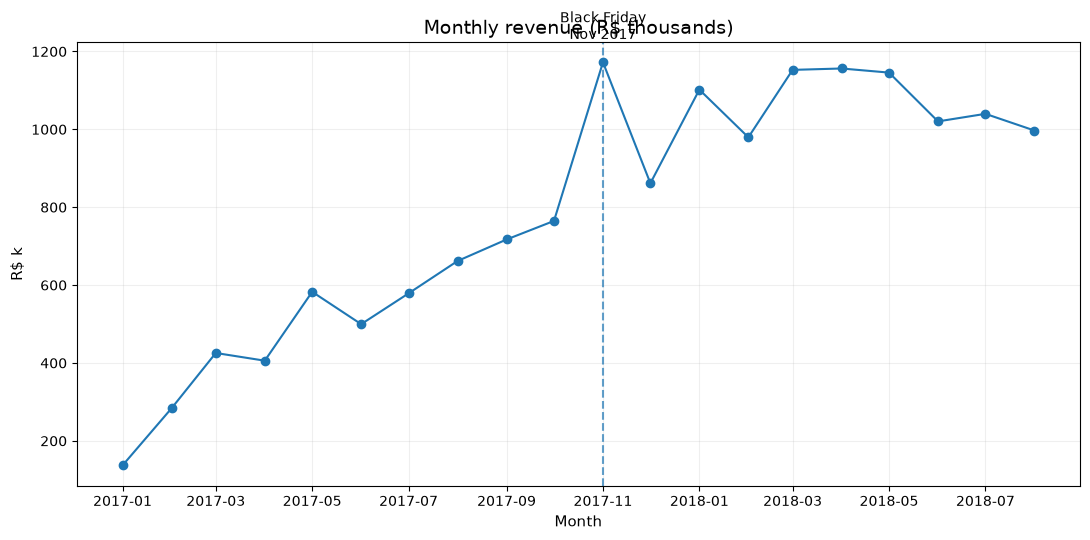

In [9]:
monthly = monthly_sales.sort_values("month_start").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(monthly["month_start"], monthly["total_revenue"] / 1000, marker="o")

peak_month = pd.to_datetime(sales["peak_month"] + "-01")
ax.axvline(peak_month, linestyle="--", alpha=0.7)
ax.annotate(
    "Black Friday\nNov 2017",
    xy=(peak_month, sales["peak_month_revenue"] / 1000),
    xytext=(peak_month, sales["peak_month_revenue"] / 1000 + 60),
    ha="center",
)

ax.set_title("Monthly revenue (R$ thousands)")
ax.set_xlabel("Month")
ax.set_ylabel("R$ k")
ax.grid(alpha=0.2)

save_chart("01_monthly_revenue.png")
plt.show()


## 7. Revenue from monthly top-50 products by category

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\02_top50_revenue_by_category.png


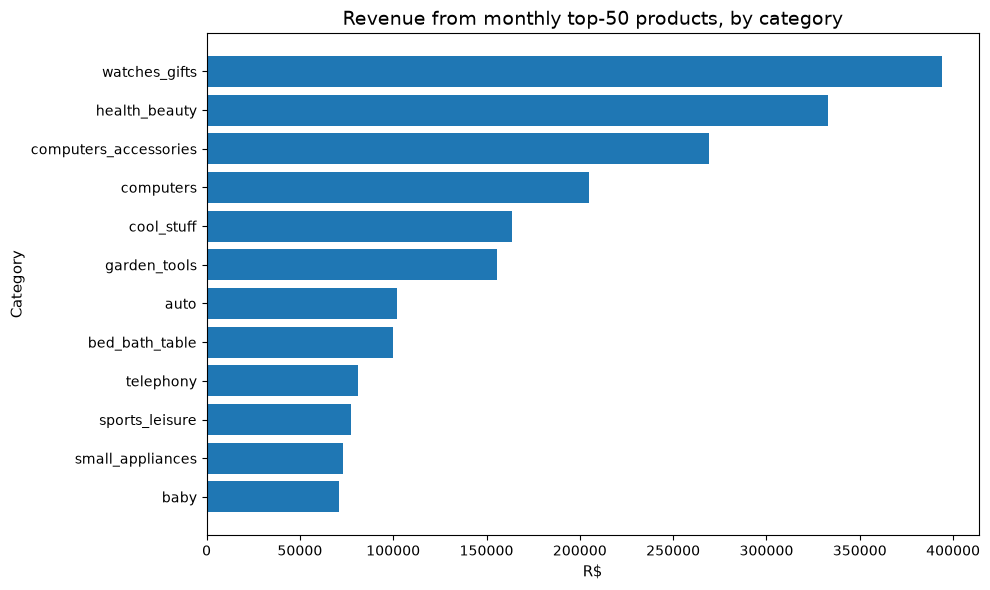

In [10]:
top50_by_category = (
    top50_products
    .groupby("category", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(12)
)

plot_df = top50_by_category.sort_values("revenue")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["category"], plot_df["revenue"])
ax.set_title("Revenue from monthly top-50 products, by category")
ax.set_xlabel("R$")
ax.set_ylabel("Category")

save_chart("02_top50_revenue_by_category.png")
plt.show()


## 8. Top categories and customer states by revenue

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\03_categories_and_states.png


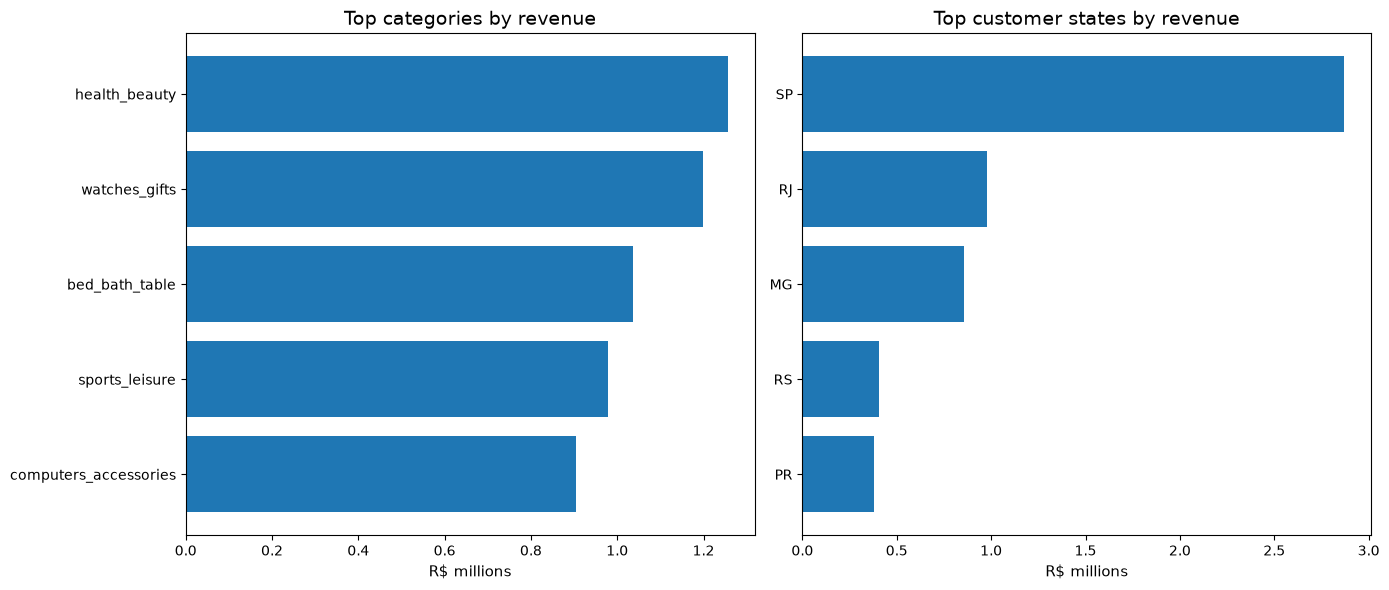

In [11]:
top_categories = pd.DataFrame(
    list(sales["top_categories_overall"].items()),
    columns=["category", "revenue"],
).sort_values("revenue", ascending=False)

state_cols = [c for c in category_state.columns if c != "category"]
state_revenue = pd.DataFrame({
    "customer_state": state_cols,
    "revenue": [category_state[c].sum() for c in state_cols],
}).sort_values("revenue", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_plot = top_categories.sort_values("revenue")
axes[0].barh(cat_plot["category"], cat_plot["revenue"] / 1_000_000)
axes[0].set_title("Top categories by revenue")
axes[0].set_xlabel("R$ millions")

state_plot = state_revenue.sort_values("revenue")
axes[1].barh(state_plot["customer_state"], state_plot["revenue"] / 1_000_000)
axes[1].set_title("Top customer states by revenue")
axes[1].set_xlabel("R$ millions")

save_chart("03_categories_and_states.png")
plt.show()


## 9. Revenue share by customer segment

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\04_segment_revenue_share.png


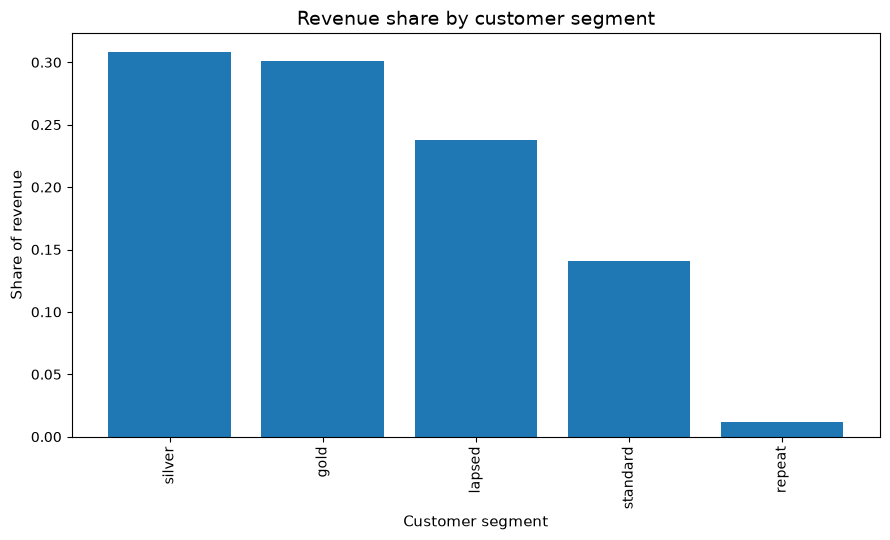

In [12]:
segment_plot = customer_segments.sort_values("revenue_share", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(segment_plot["customer_segment"], segment_plot["revenue_share"])
ax.set_title("Revenue share by customer segment")
ax.set_xlabel("Customer segment")
ax.set_ylabel("Share of revenue")
ax.tick_params(axis="x", rotation=90)

save_chart("04_segment_revenue_share.png")
plt.show()


## 10. Gold-customer category preferences

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\05_gold_customer_categories.png


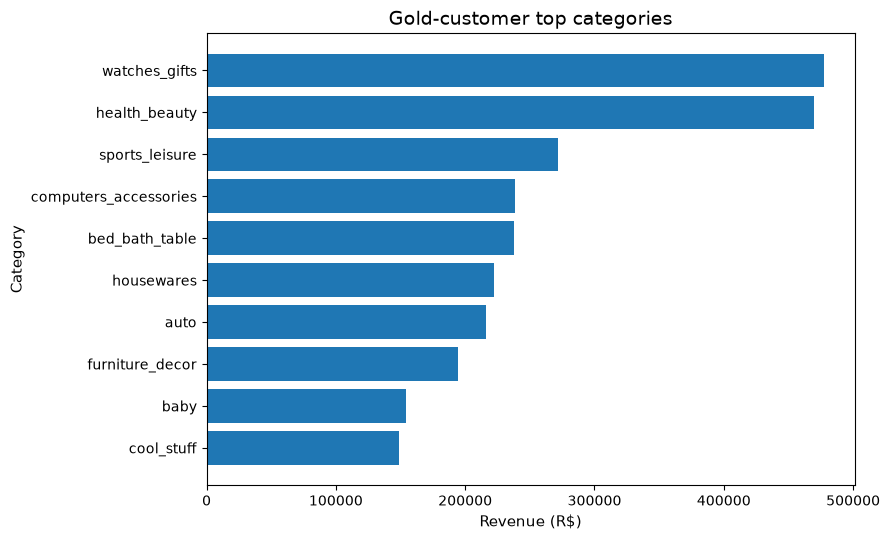

In [13]:
gold_plot = gold_categories.sort_values("revenue").tail(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(gold_plot["category"], gold_plot["revenue"])
ax.set_title("Gold-customer top categories")
ax.set_xlabel("Revenue (R$)")
ax.set_ylabel("Category")

save_chart("05_gold_customer_categories.png")
plt.show()


## 11. Delivery journey by customer state

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\06_delivery_days_by_state.png


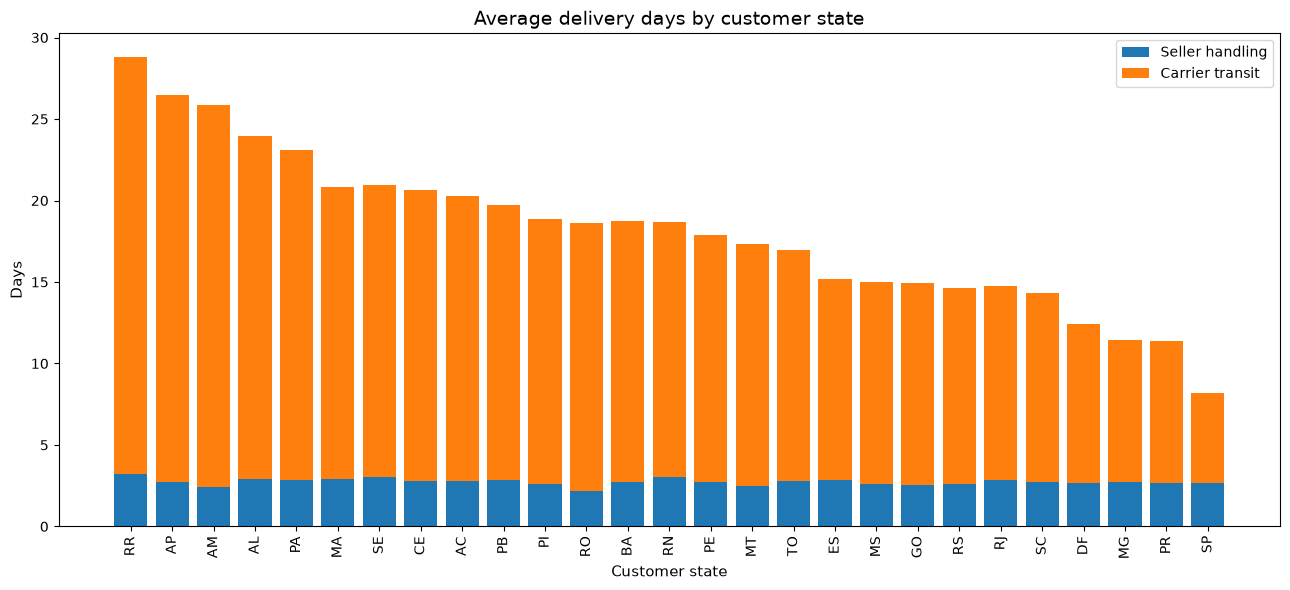

In [14]:
delivery_plot = delivery_state.sort_values("avg_delivery_days", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    delivery_plot["customer_state"],
    delivery_plot["avg_seller_handling_days"],
    label="Seller handling",
)
ax.bar(
    delivery_plot["customer_state"],
    delivery_plot["avg_carrier_transit_days"],
    bottom=delivery_plot["avg_seller_handling_days"],
    label="Carrier transit",
)

ax.set_title("Average delivery days by customer state")
ax.set_xlabel("Customer state")
ax.set_ylabel("Days")
ax.legend()
ax.tick_params(axis="x", rotation=90)

save_chart("06_delivery_days_by_state.png")
plt.show()


## 12. Delivery days vs late-delivery rate

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\07_delivery_days_vs_late_rate.png


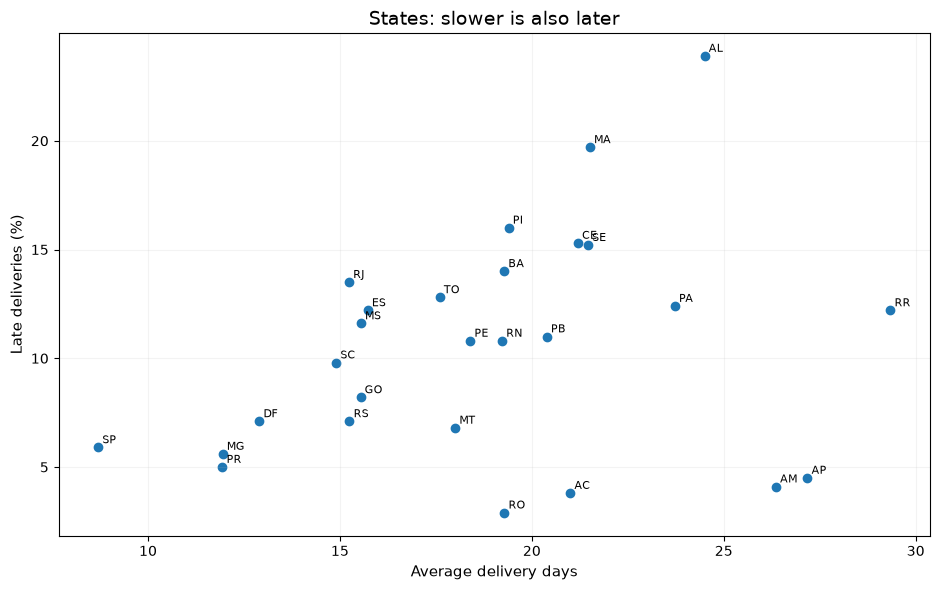

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 6))

ax.scatter(
    delivery_state["avg_delivery_days"],
    delivery_state["late_rate"] * 100,
)

for _, row in delivery_state.iterrows():
    ax.annotate(
        row["customer_state"],
        (row["avg_delivery_days"], row["late_rate"] * 100),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points",
    )

ax.set_title("States: slower is also later")
ax.set_xlabel("Average delivery days")
ax.set_ylabel("Late deliveries (%)")
ax.grid(alpha=0.15)

save_chart("07_delivery_days_vs_late_rate.png")
plt.show()


## 13. Order volume vs late-delivery rate by month

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\08_volume_vs_late_rate.png


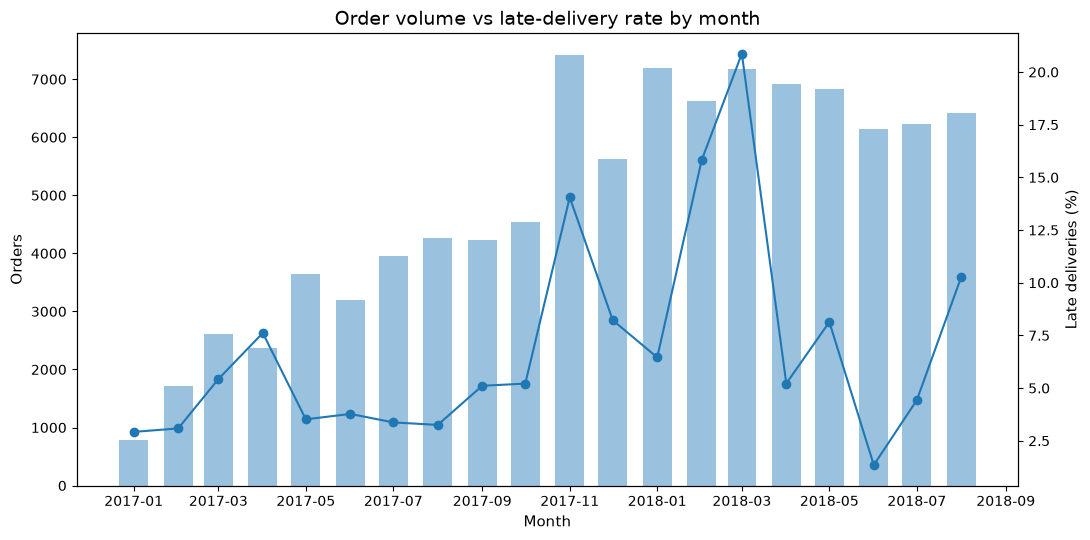

In [16]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))

ax1.bar(monthly["month_start"], monthly["orders"], width=20, alpha=0.45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Orders")

ax2 = ax1.twinx()
ax2.plot(
    monthly["month_start"],
    monthly["late_delivery_rate"] * 100,
    marker="o",
)
ax2.set_ylabel("Late deliveries (%)")

ax1.set_title("Order volume vs late-delivery rate by month")

save_chart("08_volume_vs_late_rate.png")
plt.show()


## 14. Top sellers by revenue

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\09_top_sellers.png


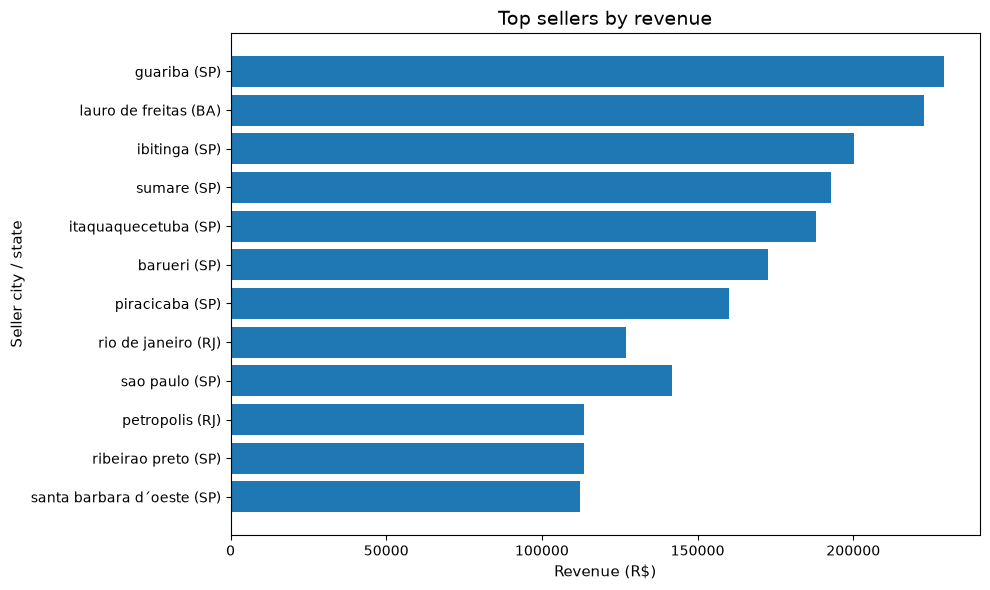

In [17]:
seller_plot = top50_sellers.sort_values("revenue", ascending=False).head(15).copy()
seller_plot["seller_label"] = (
    seller_plot["seller_city"].astype(str)
    + " ("
    + seller_plot["seller_state"].astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = seller_plot.sort_values("revenue")
ax.barh(plot_df["seller_label"], plot_df["revenue"])
ax.set_title("Top sellers by revenue")
ax.set_xlabel("Revenue (R$)")
ax.set_ylabel("Seller city / state")

save_chart("09_top_sellers.png")
plt.show()


## 15. Executive dashboard

Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\10_executive_dashboard.png


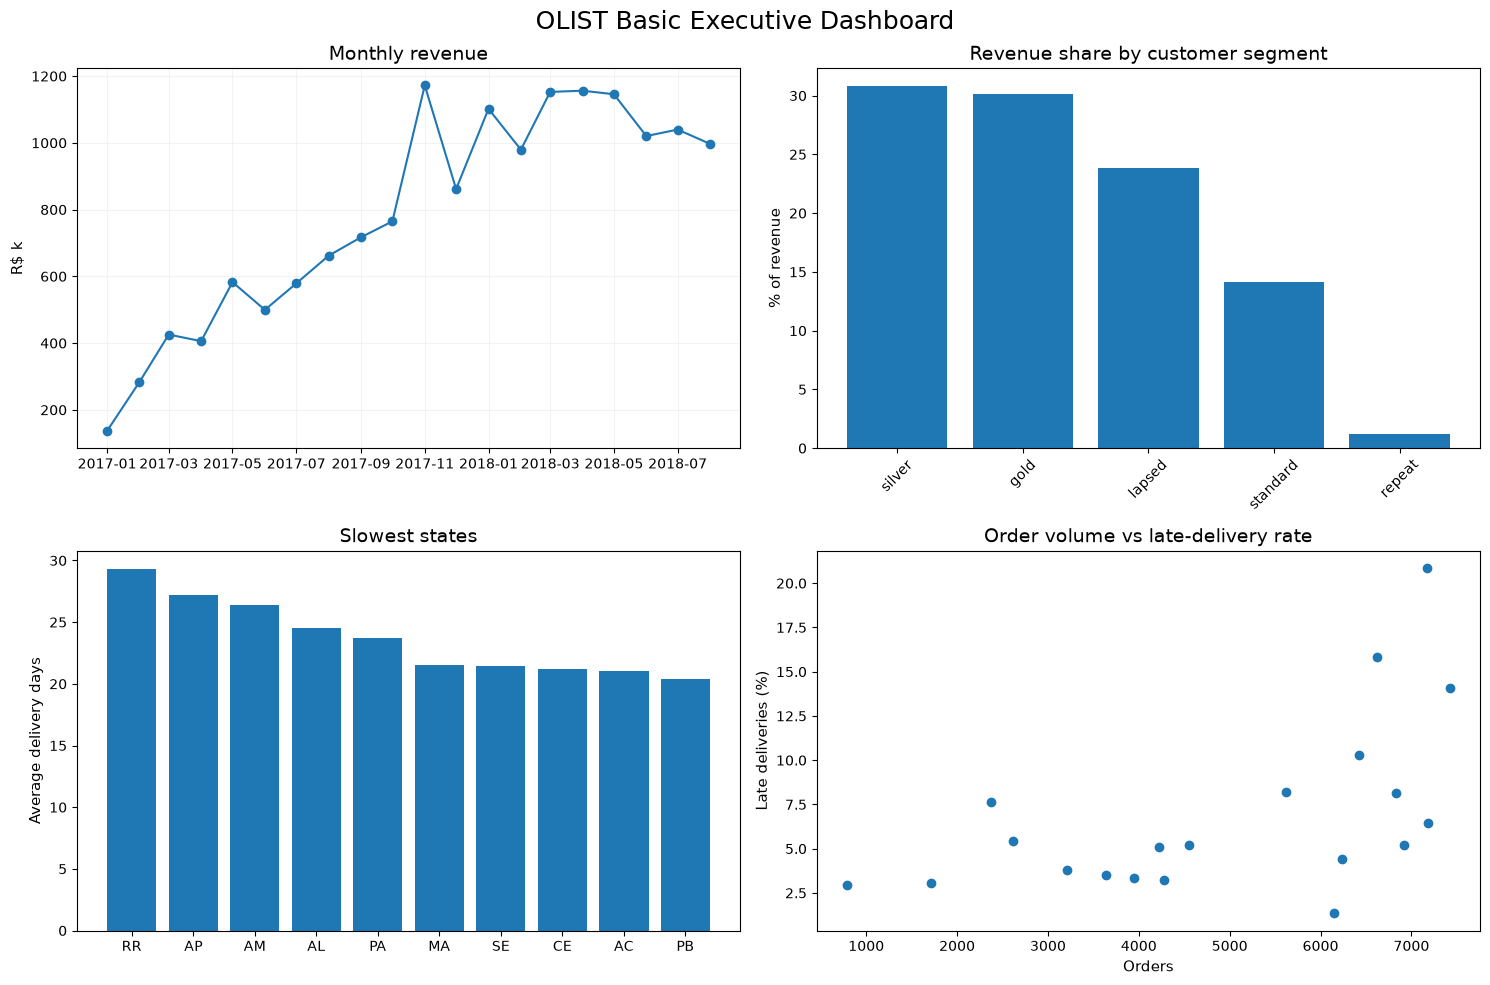

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(monthly["month_start"], monthly["total_revenue"] / 1000, marker="o")
axes[0, 0].set_title("Monthly revenue")
axes[0, 0].set_ylabel("R$ k")
axes[0, 0].grid(alpha=0.15)

axes[0, 1].bar(segment_plot["customer_segment"], segment_plot["revenue_share"] * 100)
axes[0, 1].set_title("Revenue share by customer segment")
axes[0, 1].set_ylabel("% of revenue")
axes[0, 1].tick_params(axis="x", rotation=45)

state_short = delivery_state.sort_values("avg_delivery_days", ascending=False).head(10)
axes[1, 0].bar(state_short["customer_state"], state_short["avg_delivery_days"])
axes[1, 0].set_title("Slowest states")
axes[1, 0].set_ylabel("Average delivery days")

axes[1, 1].scatter(monthly["orders"], monthly["late_delivery_rate"] * 100)
axes[1, 1].set_title("Order volume vs late-delivery rate")
axes[1, 1].set_xlabel("Orders")
axes[1, 1].set_ylabel("Late deliveries (%)")

fig.suptitle("OLIST Basic Executive Dashboard", fontsize=18)

save_chart("10_executive_dashboard.png")
plt.show()


## 16. Management findings

In [19]:
findings = pd.DataFrame([
    {
        "theme": "Sales",
        "finding": "Peak revenue month",
        "evidence": f"{sales['peak_month']} generated R$ {sales['peak_month_revenue']:,.0f}",
        "implication": "Seasonal demand should be included in campaign and capacity planning.",
    },
    {
        "theme": "Customer",
        "finding": "Low repeat-customer rate",
        "evidence": f"Only {sales['repeat_customer_rate']:.1%} of customers are repeat customers",
        "implication": "Retention is an important growth opportunity alongside acquisition.",
    },
    {
        "theme": "Customer",
        "finding": "Gold customers contribute disproportionate revenue",
        "evidence": f"Gold customers contribute {sales['gold_revenue_share']:.1%} of revenue",
        "implication": "Protect service quality and availability for high-value customer segments.",
    },
    {
        "theme": "Delivery",
        "finding": "National delivery performance",
        "evidence": (
            f"Average delivery is {delivery['national_avg_delivery_days']:.1f} days "
            f"with a {delivery['national_late_rate']:.1%} late-delivery rate"
        ),
        "implication": "Use state-level diagnostics to target delivery improvement.",
    },
    {
        "theme": "Delivery",
        "finding": "Carrier transit dominates the journey",
        "evidence": (
            f"Seller handling averages {delivery['national_leg_days']['seller']:.1f} days "
            f"versus {delivery['national_leg_days']['carrier']:.1f} carrier days"
        ),
        "implication": "Carrier/network performance deserves more attention than seller handling alone.",
    },
])

display(findings)

findings_path = OUTPUT_DIR / "basic_findings.csv"
findings.to_csv(findings_path, index=False)
print("Saved:", findings_path)


,theme,finding,evidence,implication
0,Sales,Peak revenue month,"2017-11 generated R$ 1,172,192",Seasonal demand should be included in campaign...
1,Customer,Low repeat-customer rate,Only 3.0% of customers are repeat customers,Retention is an important growth opportunity a...
2,Customer,Gold customers contribute disproportionate rev...,Gold customers contribute 30.1% of revenue,Protect service quality and availability for h...
3,Delivery,National delivery performance,Average delivery is 12.5 days with a 8.1% late...,Use state-level diagnostics to target delivery...
4,Delivery,Carrier transit dominates the journey,Seller handling averages 2.7 days versus 9.3 c...,Carrier/network performance deserves more atte...


Saved: C:\Users\mbach\Documents\olist-data-platform\analysis\outputs\basic_findings.csv


## 17. Files saved

All generated images and the findings CSV are saved directly into:

`C:\Users\mbach\Documents\olist-data-platform\analysis\outputs`

Expected generated files:

```text
01_monthly_revenue.png
02_top50_revenue_by_category.png
03_categories_and_states.png
04_segment_revenue_share.png
05_gold_customer_categories.png
06_delivery_days_by_state.png
07_delivery_days_vs_late_rate.png
08_volume_vs_late_rate.png
09_top_sellers.png
10_executive_dashboard.png
basic_findings.csv
```
